# 1 часть: EDA

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

In [9]:
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/test.csv')

In [10]:
display(train.head())
train.info()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [11]:
print(train.isnull().sum().sort_values(ascending=False))

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


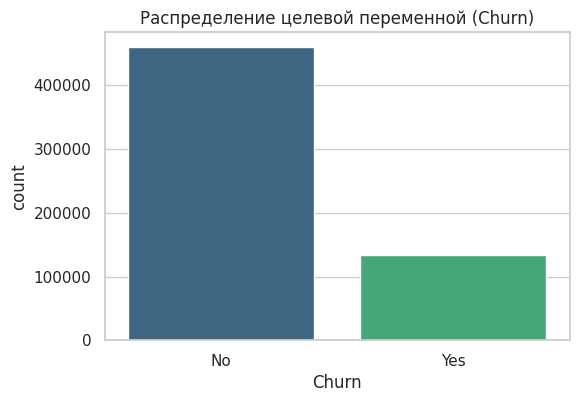

In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=train, palette='viridis')
plt.title('Распределение целевой переменной (Churn)')
plt.show()

## Предобработка и создание признаков

In [14]:
print("Варианты в колонке Contract:")
print(train['Contract'].value_counts())

Варианты в колонке Contract:
Contract
Month-to-month    298918
Two year          186943
One year          108333
Name: count, dtype: int64


In [34]:
train_len = len(train)
full_df = pd.concat([train, test], axis=0).reset_index(drop=True)

# Ищем бинарные признаки
binary_cols = []
for col in full_df.columns:
    if col not in ['id', 'Churn']:
        unique_vals = full_df[col].dropna().unique()
        if len(unique_vals) == 2:
            binary_cols.append(col)

print(f"Бинарные признаки: {binary_cols}")

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in binary_cols:
    full_df[col] = le.fit_transform(full_df[col].astype(str))

# Feature Engineering
def add_features(df):
    # Логарифмируем денежные признаки, чтобы сгладить выбросы
    df['Log_MonthlyCharges'] = np.log1p(df['MonthlyCharges'])
    df['Log_TotalCharges'] = np.log1p(df['TotalCharges'])
    
    # Отношение tenure к контракту (насколько "предан" клиент)
    contract_map = {'Month-to-month': 1, 'One year': 12, 'Two year': 24}
    temp_contract = df['Contract'].map(contract_map).fillna(1)
    df['Tenure_Contract_Ratio'] = df['tenure'] / temp_contract
    
    # Количество сервисов
    service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                    'TechSupport', 'StreamingTV', 'StreamingMovies']
    df['TotalServices'] = (df[service_cols] == 'Yes').sum(axis=1)
    
    return df

full_df = add_features(full_df)

full_df['Churn'] = full_df['Churn'].map({'Yes': 1, 'No': 0})

train_df = full_df[:train_len].copy()
test_df = full_df[train_len:].copy()

X = train_df.drop(['id', 'Churn'], axis=1)
y = train_df['Churn']
X_test = test_df.drop(['id', 'Churn'], axis=1)
test_ids = test_df['id']

print(f"Готово! Число признаков после обработки: {X.shape[1]}")

Бинарные признаки: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Готово! Число признаков после обработки: 23


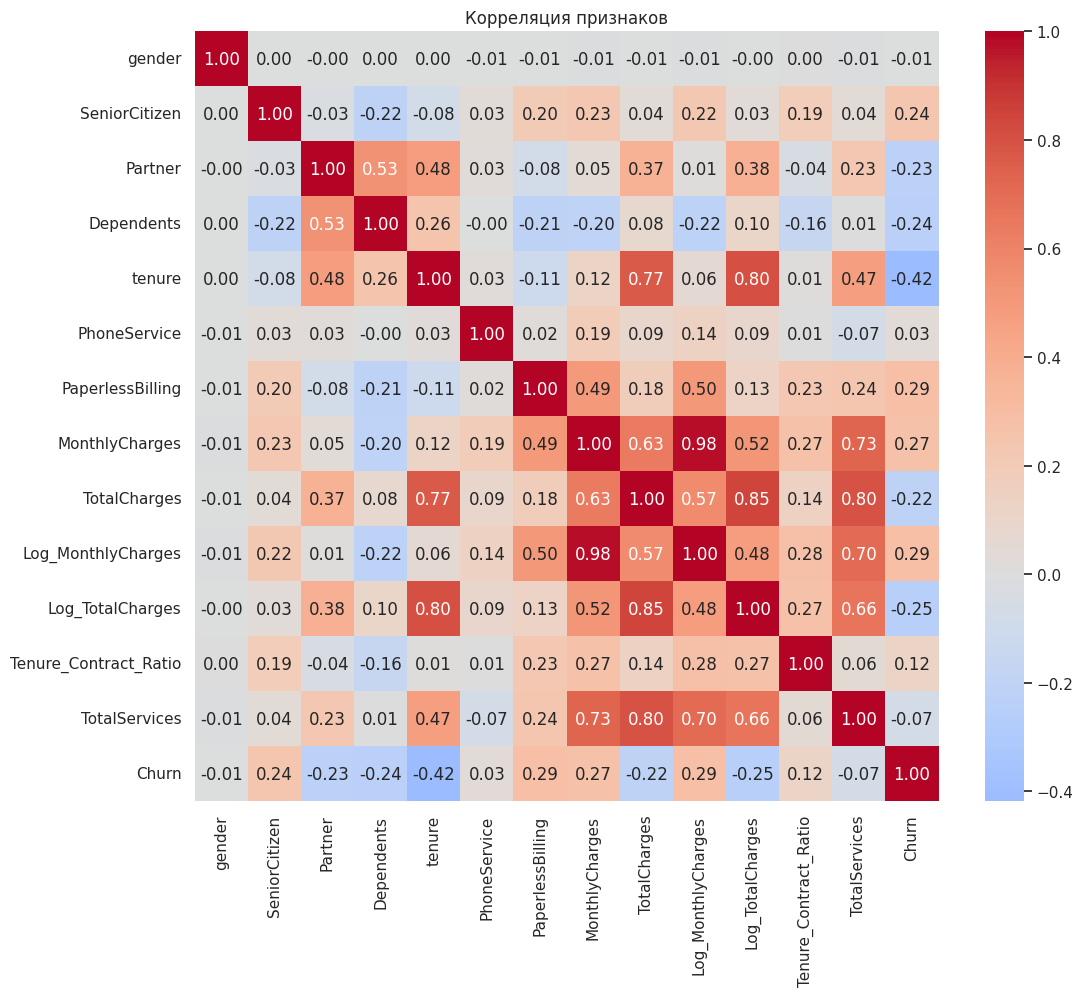

In [35]:
num_features = train_df.select_dtypes(include=[np.number]).columns.tolist()
num_features = [f for f in num_features if f not in ['id', 'Churn']]

# Матрица корреляции
plt.figure(figsize=(12, 10))
corr_matrix = train_df[num_features + ['Churn']].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Корреляция признаков')
plt.show()

# 2 часть: Создание и обучение модели

## Сначала через CatBoosting

In [38]:
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

cat_features = X.select_dtypes(include=['object']).columns.tolist()

params = {
    'iterations': 1000,
    'learning_rate': 0.03,
    'depth': 6,
    'l2_leaf_reg': 3.5,
    'bootstrap_type': 'Bernoulli',
    'subsample': 0.8,
    'eval_metric': 'AUC',
    'early_stopping_rounds': 100,
    'random_seed': 42,
    'verbose': 100
}

n_splits = 5 # Кол-во холдов
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test))


for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = CatBoostClassifier(**params)
    
    model.fit(
        X_train, y_train,
        cat_features=cat_features,
        eval_set=(X_val, y_val),
        use_best_model=True
    )
    
    # Предсказываем вероятности для валидационной части
    batch_val_preds = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = batch_val_preds
    
    # Сразу предсказываем для теста
    test_preds += model.predict_proba(X_test)[:, 1] / n_splits
    
    fold_auc = roc_auc_score(y_val, batch_val_preds)
    print(f"Fold {fold+1} завершен. ROC-AUC: {fold_auc:.5f}")

overall_auc = roc_auc_score(y, oof_preds)
print(f"\nИтоговый ROC-AUC: {overall_auc:.5f}")

0:	test: 0.8881962	best: 0.8881962 (0)	total: 916ms	remaining: 15m 15s
100:	test: 0.9106560	best: 0.9106560 (100)	total: 1m 8s	remaining: 10m 8s
200:	test: 0.9123416	best: 0.9123416 (200)	total: 2m 13s	remaining: 8m 52s
300:	test: 0.9130624	best: 0.9130624 (300)	total: 3m 18s	remaining: 7m 41s
400:	test: 0.9135090	best: 0.9135090 (400)	total: 4m 22s	remaining: 6m 31s
500:	test: 0.9139736	best: 0.9139736 (500)	total: 5m 31s	remaining: 5m 30s
600:	test: 0.9143947	best: 0.9143947 (600)	total: 6m 44s	remaining: 4m 28s
700:	test: 0.9146783	best: 0.9146783 (700)	total: 7m 54s	remaining: 3m 22s
800:	test: 0.9148995	best: 0.9148995 (800)	total: 9m 6s	remaining: 2m 15s
900:	test: 0.9150712	best: 0.9150712 (900)	total: 10m 16s	remaining: 1m 7s
999:	test: 0.9152254	best: 0.9152254 (999)	total: 11m 25s	remaining: 0us

bestTest = 0.9152254351
bestIteration = 999

Fold 1 завершен. ROC-AUC: 0.91523
0:	test: 0.8889907	best: 0.8889907 (0)	total: 800ms	remaining: 13m 18s
100:	test: 0.9119586	best: 0.911

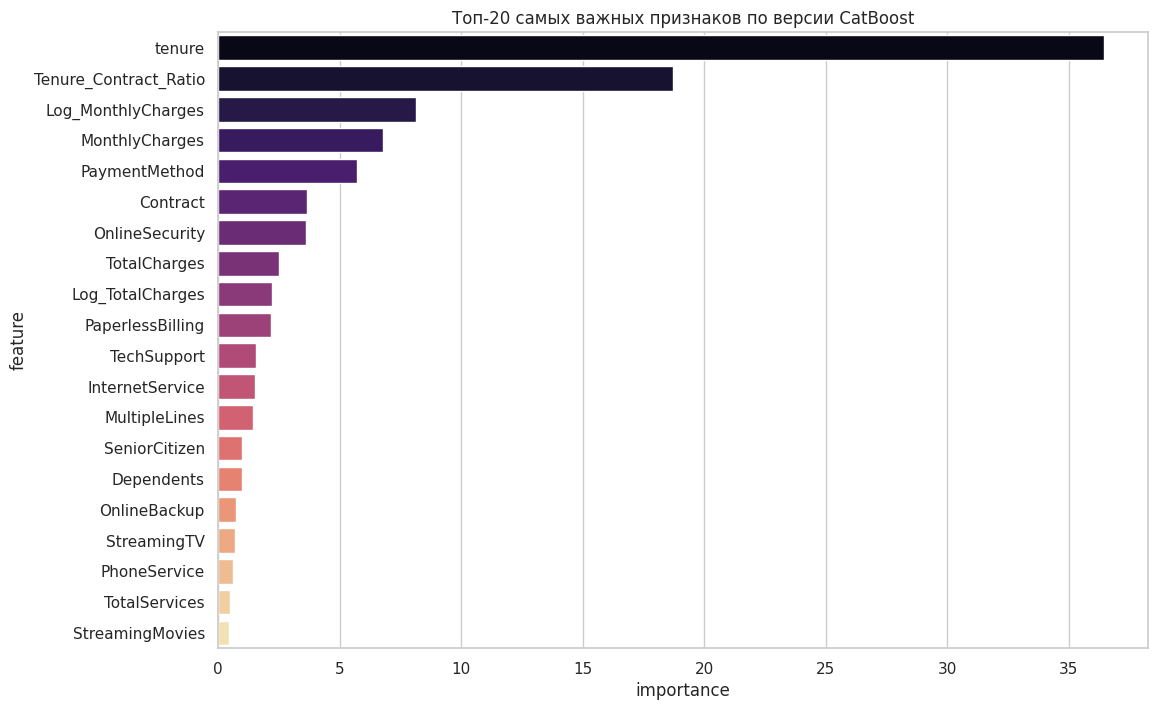

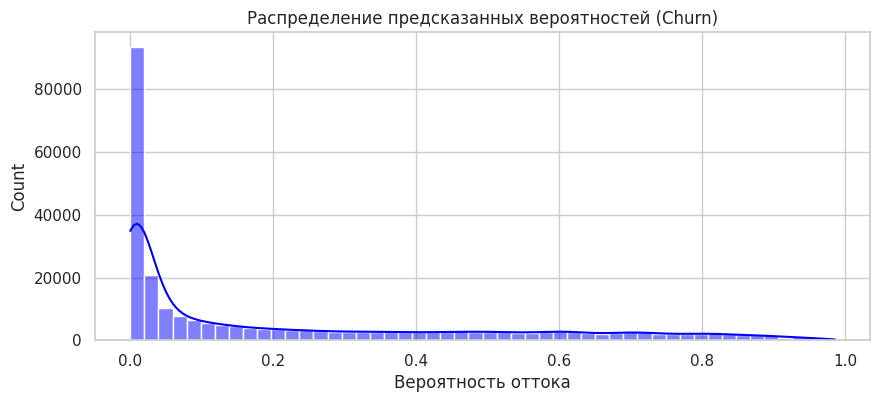

In [40]:
submission = pd.DataFrame({
    'id': test_ids,
    'Churn': test_preds
})

submission.to_csv('submission_CB.csv', index=False)

# Анализ важности признаков
feature_importance = model.get_feature_importance()
feature_names = X.columns
data = pd.DataFrame({'feature': feature_names, 'importance': feature_importance})
data = data.sort_values(by='importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=data.head(20), palette='magma')
plt.title('Топ-20 самых важных признаков по версии CatBoost')
plt.show()

# Выведем распределение предсказаний
plt.figure(figsize=(10, 4))
sns.histplot(submission['Churn'], bins=50, kde=True, color='blue')
plt.title('Распределение предсказанных вероятностей (Churn)')
plt.xlabel('Вероятность оттока')
plt.show()

## Дополним ещё LightGBM

In [42]:
import lightgbm as lgb

lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'n_estimators': 1000,
    'learning_rate': 0.03,
    'num_leaves': 31,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'max_depth': -1,
    'seed': 42,
    'verbose': -1
}

lgbm_test_preds = np.zeros(len(X_test))
lgbm_oof_preds = np.zeros(len(X))


for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    X_train_lgb = X_train.copy()
    X_val_lgb = X_val.copy()
    for col in cat_features:
        X_train_lgb[col] = X_train_lgb[col].astype('category')
        X_val_lgb[col] = X_val_lgb[col].astype('category')

    model_lgb = lgb.LGBMClassifier(**lgb_params)
    
    model_lgb.fit(
        X_train_lgb, y_train,
        eval_set=[(X_val_lgb, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(0)]
    )
    
    lgbm_oof_preds[val_idx] = model_lgb.predict_proba(X_val_lgb)[:, 1]
    
    # Подготовка теста для предсказания
    X_test_lgb = X_test.copy()
    for col in cat_features:
        X_test_lgb[col] = X_test_lgb[col].astype('category')
    
    lgbm_test_preds += model_lgb.predict_proba(X_test_lgb)[:, 1] / n_splits
    
    fold_auc = roc_auc_score(y_val, lgbm_oof_preds[val_idx])
    print(f"Fold {fold+1} завершен. ROC-AUC: {fold_auc:.5f}")

print(f"LGBM AUC: {roc_auc_score(y, lgbm_oof_preds):.5f}")

Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's auc: 0.91592
Fold 1 завершен. ROC-AUC: 0.91592
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[992]	valid_0's auc: 0.917008
Fold 2 завершен. ROC-AUC: 0.91701
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[982]	valid_0's auc: 0.916191
Fold 3 завершен. ROC-AUC: 0.91619
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's auc: 0.91731
Fold 4 завершен. ROC-AUC: 0.91731
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's auc: 0.914643
Fold 5 завершен. ROC-AUC: 0.91464
LGBM AUC: 0.91620


In [48]:
cb_auc = roc_auc_score(y, oof_preds)
lgb_auc = roc_auc_score(y, lgbm_oof_preds)

# Создаем финальный бленд 
final_oof = oof_preds * 0.2 + lgbm_oof_preds * 0.8
blend_auc = roc_auc_score(y, final_oof)

print(f"CatBoost AUC: {cb_auc:.5f}")
print(f"LightGBM AUC: {lgb_auc:.5f}")
print(f"Blend AUC: {blend_auc:.5f}")

final_test_preds = (test_preds + lgbm_test_preds) / 2
submission_blend = pd.DataFrame({'id': test_ids, 'Churn': final_test_preds})
submission_blend.to_csv('submission_blend.csv', index=False)

CatBoost AUC: 0.91563
LightGBM AUC: 0.91620
Blend AUC: 0.91625
